# Exploratory Data Analysis — ML Stock Direction Predictor

**Purpose**: Document the initial research phase that motivated the design choices in our production pipeline.

This notebook answers three questions:
1. Is the binary target (`UP` / `DOWN`) class-balanced? Should we apply weighting?
2. How do our engineered features correlate with the next-day direction?
3. Why are raw prices non-stationary, and how do our transformations fix that?

---


In [1]:
import sys
import os
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')


Libraries loaded.


## 1. Class Imbalance Analysis

We download 5 years of AAPL daily bars and label each day with the next-day direction (`1 = UP`, `0 = DOWN`).  A skewed distribution would mean a naive classifier could achieve high accuracy simply by always predicting the majority class — masking poor real-world performance.

The countplot below visualises the split. Any ratio beyond **55 / 45** warrants balanced class weighting during training.


Date range : 2021-05-17  →  2026-05-14
Total days : 1,255
UP   (1)   : 667  (53.1 %)
DOWN (0)   : 588  (46.9 %)


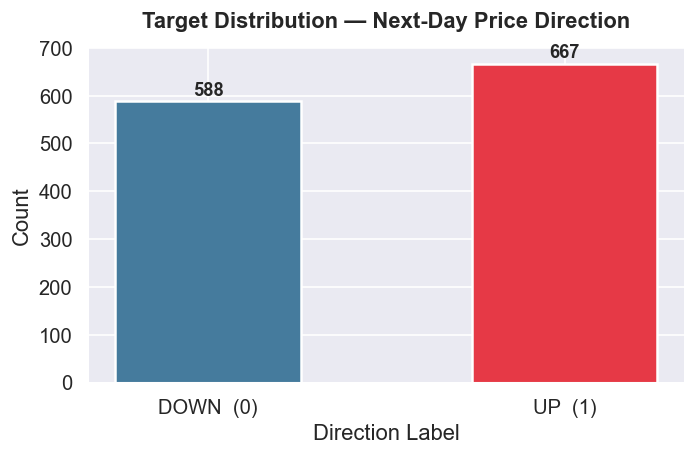

In [2]:
# ── Download data ────────────────────────────────────────────────────────────
raw = yf.download('AAPL', period='5y', auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

# ── Engineer target ───────────────────────────────────────────────────────────
raw['Next_Close'] = raw['Close'].shift(-1)
raw['Target']     = (raw['Next_Close'] > raw['Close']).astype(int)
raw.dropna(inplace=True)

up_count   = int(raw['Target'].sum())
down_count = int((raw['Target'] == 0).sum())
up_pct     = raw['Target'].mean() * 100

print(f'Date range : {raw.index[0].date()}  →  {raw.index[-1].date()}')
print(f'Total days : {len(raw):,}')
print(f'UP   (1)   : {up_count:,}  ({up_pct:.1f} %)')
print(f'DOWN (0)   : {down_count:,}  ({100 - up_pct:.1f} %)')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
counts  = [down_count, up_count]
labels  = ['DOWN  (0)', 'UP  (1)']
colors  = ['#457b9d', '#e63946']
bars    = ax.bar(labels, counts, color=colors, width=0.52,
                 edgecolor='white', linewidth=1.5)

for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4,
        f'{count:,}',
        ha='center', va='bottom', fontsize=11, fontweight='bold',
    )

ax.set_title('Target Distribution — Next-Day Price Direction',
             fontweight='bold', pad=12)
ax.set_xlabel('Direction Label')
ax.set_ylabel('Count')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## 2. Feature Correlation Matrix

We engineer the same 10 features used by the production pipeline and compute the Pearson correlation between every feature pair and the `Target`.

Key things to look for:
- **High inter-feature correlation** (e.g. `SMA_5` vs `SMA_20`) — suggests redundancy; regularisation (Ridge, Dropout) is important.
- **Low feature-target correlation** — stock direction is notoriously hard to predict; small correlations (~0.02–0.10) are typical and realistic.


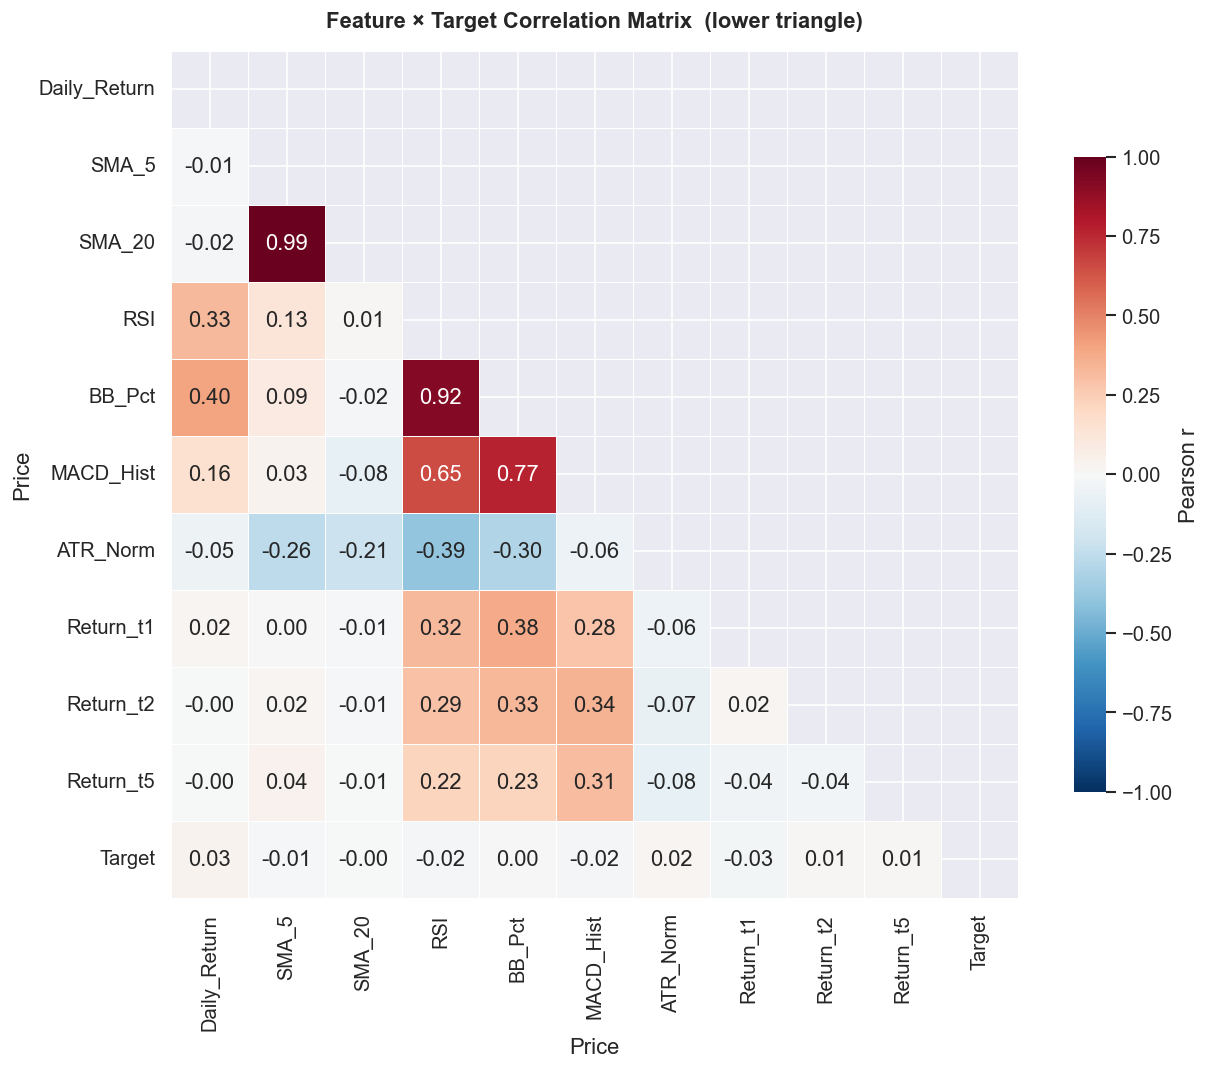


Correlation with Target (ranked by |r|):
Price
Daily_Return    0.031297
Return_t1      -0.028824
MACD_Hist      -0.021703
RSI            -0.021417
ATR_Norm        0.019029
Return_t2       0.013323
Return_t5       0.011793
SMA_5          -0.010176
SMA_20         -0.004772
BB_Pct          0.001289


In [3]:
df = raw.copy()

# ── Compute all 10 production features ───────────────────────────────────────

# Core momentum / trend
df['Daily_Return'] = df['Close'].pct_change()
df['SMA_5']        = df['Close'].rolling(5).mean()
df['SMA_20']       = df['Close'].rolling(20).mean()

# RSI (Wilder EMA)
delta    = df['Close'].diff()
gain     = delta.clip(lower=0)
loss     = -delta.clip(upper=0)
avg_gain = gain.ewm(com=13, min_periods=14).mean()
avg_loss = loss.ewm(com=13, min_periods=14).mean()
df['RSI'] = 100.0 - 100.0 / (1.0 + avg_gain / (avg_loss + 1e-10))

# Bollinger %B
roll_mean  = df['Close'].rolling(20).mean()
roll_std   = df['Close'].rolling(20).std()
bb_upper   = roll_mean + 2 * roll_std
bb_lower   = roll_mean - 2 * roll_std
df['BB_Pct'] = (df['Close'] - bb_lower) / (bb_upper - bb_lower + 1e-10)

# MACD Histogram
ema12          = df['Close'].ewm(span=12, adjust=False, min_periods=26).mean()
ema26          = df['Close'].ewm(span=26, adjust=False, min_periods=26).mean()
macd_line      = ema12 - ema26
macd_signal    = macd_line.ewm(span=9, adjust=False, min_periods=9).mean()
df['MACD_Hist'] = macd_line - macd_signal

# ATR normalised by price
high_low  = df['High'] - df['Low']
high_pc   = (df['High'] - df['Close'].shift(1)).abs()
low_pc    = (df['Low']  - df['Close'].shift(1)).abs()
tr        = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
atr       = tr.ewm(com=13, min_periods=14).mean()
df['ATR_Norm'] = atr / (df['Close'] + 1e-10)

# Lagged returns (sequence context)
df['Return_t1'] = df['Daily_Return'].shift(1)
df['Return_t2'] = df['Daily_Return'].shift(2)
df['Return_t5'] = df['Daily_Return'].shift(5)

df.dropna(inplace=True)

# ── Correlation matrix ────────────────────────────────────────────────────────
feature_cols = [
    'Daily_Return', 'SMA_5', 'SMA_20', 'RSI',
    'BB_Pct', 'MACD_Hist', 'ATR_Norm',
    'Return_t1', 'Return_t2', 'Return_t5', 'Target',
]
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1, center=0,
    square=True,
    linewidths=0.4,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
    ax=ax,
)
ax.set_title('Feature × Target Correlation Matrix  (lower triangle)',
             fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

# Print Target correlations ranked
target_corr = corr['Target'].drop('Target').sort_values(key=abs, ascending=False)
print('\nCorrelation with Target (ranked by |r|):')
print(target_corr.to_string())


## 3. Stationarity and Feature Design Rationale

### Why raw prices are non-stationary

A time series is **covariance-stationary** if its mean and variance are constant over time and its autocovariance depends only on the lag, not the absolute time index.

AAPL's closing price violates both conditions:
- The **mean** drifts from ~$10 in 2014 to ~$200 in 2024 (upward secular trend).
- The **variance** grows proportionally with the price level (heteroscedasticity).

A model trained on 2014–2018 price levels will have zero meaningful signal when deployed on 2022–2024 data — the distributions it learned no longer exist.

---

### How our feature transformations restore stationarity

| Feature | Transformation | Why it achieves stationarity |
|---------|---------------|------------------------------|
| `Daily_Return` | `(Close[T] - Close[T-1]) / Close[T-1]` | Returns are approximately i.i.d. with near-zero mean regardless of price level |
| `ATR_Norm` | `ATR(14) / Close[T]` | Dividing by price removes scale drift; yields a dimensionless volatility ratio that is comparable across all price levels |
| `RSI` | Wilder EMA of gains / losses | Bounded in [0, 100] by construction; mean-reverts around 50 across all market regimes |
| `BB_Pct` | `(Close - Lower) / (Upper - Lower)` | Normalised position [0, 1] relative to rolling mean; removes absolute price level entirely |
| `MACD_Hist` | `EMA(12) - EMA(26) - Signal(9)` | First-differencing of EMAs removes the price trend; histogram fluctuates around zero |
| `Return_tN` | `Daily_Return[T-N]` | Lagged percentage returns inherit the stationarity of `Daily_Return` |

**Key insight**: By transforming raw prices into **percentage returns, normalised ratios, and bounded oscillators**, all model inputs become approximately stationary. This is not just good ML hygiene — it is a **fundamental requirement** for the model to generalise across different market regimes, volatility environments, and absolute price levels.

Without these transformations, even a perfectly fitted model on the training set would systematically fail in out-of-sample periods where market conditions (price level, volatility regime) differ from the training distribution.
